# SynthFCD — Inference Notebook

Runs inference using a trained `SegNet` checkpoint on real FLAIR or T1 MRI scans.
No synthesis pipeline is involved at inference time.

### Outputs
- `predictions/` — per-subject `_seg.nii` (7-class) and `_lesion.nii` (binary FCD mask)
- `eval_lesion/` — lesion metrics vs `roi.nii` *(if `EVAL_LESION=True`)*
- `eval_full_seg/` — per-class metrics vs remapped `fusedmask.nii` *(if `EVAL_FULL_SEG=True`)*

### Class mapping (model output)
| Value | Tissue |
|-------|--------|
| 0 | Background |
| 1 | White Matter |
| 2 | Cerebral Cortex |
| 3 | Deep Gray Matter |
| 4 | CSF |
| 5 | WM-GM Separator |
| **6** | **FCD Lesion** |

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║              CONFIGURATION — edit only this cell                ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Paths ─────────────────────────────────────────────────────────────────────
CHECKPOINT_PATH      = ""
DATA_DIR             = "/kaggle/input/datasets/yassientawfikkk/augmented-fcd-lesion-mri-dataset"
SRC_CODE_DIR         = '/kaggle/input/datasets/yassientawfikkk/synth-sourcecode'
OUTPUT_DIR           = "/kaggle/working/inference_out/"

# ── Data ──────────────────────────────────────────────────────────────────────
DATA_SPLIT           = "test"    # test | train_raw | train_generated | all_fcd | hc
INPUT_MODALITY       = "flair"   # flair | t1

# ── Inference ─────────────────────────────────────────────────────────────────
NORMALIZE            = False   # True  → percentile clip (1st-99th) then rescale to [0,1]
                               # False → raw voxel values fed directly to the network

THRESHOLD            = 0.5     # class-6 softmax probability threshold (0.0 – 1.0)

# ── Evaluation: Lesion ────────────────────────────────────────────────────────
# Compares binary lesion prediction vs roi.nii
# Metrics: Dice, IoU, Precision, Recall, FP Volume, Detected flag
EVAL_LESION          = True
DETECTION_THRESHOLD  = 0.1   # min Dice to count a subject as "detected"

# ── Evaluation: Full Segmentation ─────────────────────────────────────────────
# Compares 7-class prediction vs fusedmask.nii (after remapping labels → model classes)
# Metrics: per-class Dice for all 7 structures across all subjects
EVAL_FULL_SEG        = True

# ── Model architecture — must match training config ───────────────────────────
SEG_FEATURES         = [16, 32, 64, 128, 256, 512]
SEG_NB_LEVELS        = 6
NB_CLASSES           = 7
LESION_CLASS         = 6

In [2]:
!pip install git+https://github.com/balbasty/cornucopia@6f8ab58dfcfe8978c9aa9e8b05898dcf7d75bb5b

  Cloning https://github.com/balbasty/cornucopia (to revision 6f8ab58dfcfe8978c9aa9e8b05898dcf7d75bb5b) to /tmp/pip-req-build-yj3jugqi
  Running command git clone --filter=blob:none --quiet https://github.com/balbasty/cornucopia /tmp/pip-req-build-yj3jugqi
  Running command git rev-parse -q --verify 'sha^6f8ab58dfcfe8978c9aa9e8b05898dcf7d75bb5b'
  Running command git fetch -q https://github.com/balbasty/cornucopia 6f8ab58dfcfe8978c9aa9e8b05898dcf7d75bb5b
  Running command git checkout -q 6f8ab58dfcfe8978c9aa9e8b05898dcf7d75bb5b
  Resolved https://github.com/balbasty/cornucopia to commit 6f8ab58dfcfe8978c9aa9e8b05898dcf7d75bb5b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for cornucopia: filename=cornucopia-0.4.0-py3-none-any.whl size=126230 sha256=4b83ab4e18578da092ea4fcd638984dd16d2d1299a0a07f2a05486ef65eb1469
  Stored in directory: /root/.cache/pip/wheels/a3/ea/27/98c72f0858dada2

## ⚙️ Setup
> **Do not edit this cell.** Run it once after setting configuration above.

In [5]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, sys, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import nibabel as nib
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size']  = 10

# learn2synth must be on sys.path
PACKAGE_DIR = "/kaggle/working/learn2synth"
if not os.path.exists(PACKAGE_DIR):
    os.symlink(SRC_CODE_DIR, PACKAGE_DIR)
    print(f"Created symlink → {PACKAGE_DIR}")
else:
    print(f"Symlink already exists → {PACKAGE_DIR}")

from learn2synth.networks import SegNet

# ── Validation guards ─────────────────────────────────────────────────────────
assert CHECKPOINT_PATH,                   "❌ CHECKPOINT_PATH is empty"
assert Path(CHECKPOINT_PATH).exists(),    f"❌ Checkpoint not found: {CHECKPOINT_PATH}"
assert Path(DATA_DIR).exists(),           f"❌ DATA_DIR not found: {DATA_DIR}"
assert INPUT_MODALITY in ("flair", "t1"), "❌ INPUT_MODALITY must be 'flair' or 't1'"
assert 0.0 <= THRESHOLD <= 1.0,           "❌ THRESHOLD must be between 0.0 and 1.0"
assert 0.0 <= DETECTION_THRESHOLD <= 1.0, "❌ DETECTION_THRESHOLD must be between 0.0 and 1.0"
assert DATA_SPLIT in ("test", "train_raw", "train_generated", "all_fcd", "hc"),     f"❌ Unknown DATA_SPLIT: {DATA_SPLIT}"

# ── Auto-disable eval for hc (no roi.nii / fusedmask.nii) ────────────────────
if DATA_SPLIT == "hc":
    if EVAL_LESION or EVAL_FULL_SEG:
        EVAL_LESION   = False
        EVAL_FULL_SEG = False
        print("⚠️  hc split has no ground truth → EVAL_LESION and EVAL_FULL_SEG disabled")

# ── Output directories ────────────────────────────────────────────────────────
out_root    = Path(OUTPUT_DIR)
out_pred    = out_root / "predictions"
out_lesion  = out_root / "eval_lesion"
out_fullseg = out_root / "eval_full_seg"

out_pred.mkdir(parents=True, exist_ok=True)
if EVAL_LESION:
    (out_lesion  / "metrics").mkdir(parents=True, exist_ok=True)
    (out_lesion  / "plots").mkdir(parents=True, exist_ok=True)
if EVAL_FULL_SEG:
    (out_fullseg / "metrics").mkdir(parents=True, exist_ok=True)
    (out_fullseg / "plots").mkdir(parents=True, exist_ok=True)

# ── Runtime ───────────────────────────────────────────────────────────────────
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# ── Runtime summary ───────────────────────────────────────────────────────────
print(f"PyTorch       : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
print()
print(f"Checkpoint    : {CHECKPOINT_PATH}")
print(f"Data split    : {DATA_SPLIT}")
print(f"Modality      : {INPUT_MODALITY}")
print(f"Normalize     : {NORMALIZE}")
print(f"Threshold     : {THRESHOLD}")
print(f"EVAL_LESION   : {EVAL_LESION}  (detection threshold = {DETECTION_THRESHOLD})")
print(f"EVAL_FULL_SEG : {EVAL_FULL_SEG}")
print(f"Device        : {DEVICE}")
print(f"Output dir    : {OUTPUT_DIR}")

Created symlink → /kaggle/working/learn2synth
PyTorch       : 2.6.0+cu124
CUDA available: True
GPU           : Tesla P100-PCIE-16GB

Checkpoint    : /kaggle/input/datasets/yassienmohamed/flair-synthfcd-edata-output/experiments/synthfcd_extra_data_flair/checkpoints/checkpoint-epoch=133-eval_loss=3.27-val_dice=0.58.ckpt
Data split    : test
Modality      : flair
Normalize     : False
Threshold     : 0.5
EVAL_LESION   : True  (detection threshold = 0.1)
EVAL_FULL_SEG : True
Device        : cuda
Output dir    : /kaggle/working/inference_out/synthfcd_extra_data_flair


## Subject Discovery

Scans the dataset for subjects matching the selected split.  
Subjects missing required files are skipped with a warning.

| Split | Directory |
|-------|-----------|
| `test` | `fcd/test/` |
| `train_raw` | `fcd/train/raw/` |
| `train_generated` | `fcd/train/generated/` |
| `all_fcd` | all three above |
| `hc` | `hc/` — no ground truth, eval disabled |

In [6]:
SPLIT_PATHS = {
    "test":            ["fcd/test"],
    "train_raw":       ["fcd/train/raw"],
    "train_generated": ["fcd/train/generated"],
    "all_fcd":         ["fcd/test", "fcd/train/raw", "fcd/train/generated"],
    "hc":              ["hc"],
}


def discover_subjects(data_dir, split, modality, eval_lesion, eval_full_seg):
    """
    Walk the dataset and return valid subjects as a list of dicts:
        id             : str   e.g. 'sub-00004'
        modality_path  : Path  flair.nii or t1.nii
        roi_path       : Path | None
        fusedmask_path : Path | None
        pool           : str   sub-directory label
    """
    data_dir      = Path(data_dir)
    modality_file = f"{modality}.nii"
    subjects, skipped = [], []

    for pool_rel in SPLIT_PATHS[split]:
        pool_path = data_dir / pool_rel
        if not pool_path.exists():
            print(f"⚠️  Pool not found, skipping: {pool_path}")
            continue

        for sub_dir in sorted(pool_path.iterdir()):
            if not sub_dir.is_dir() or not sub_dir.name.startswith("sub-"):
                continue

            mod_path      = sub_dir / modality_file
            roi_path      = sub_dir / "roi.nii"
            fusedmask_path = sub_dir / "fusedmask.nii"

            missing = []
            if not mod_path.exists():
                missing.append(modality_file)
            if eval_lesion   and not roi_path.exists():
                missing.append("roi.nii")
            if eval_full_seg and not fusedmask_path.exists():
                missing.append("fusedmask.nii")

            if missing:
                skipped.append((sub_dir.name, missing))
                continue

            subjects.append({
                "id"            : sub_dir.name,
                "modality_path" : mod_path,
                "roi_path"      : roi_path       if roi_path.exists()       else None,
                "fusedmask_path": fusedmask_path if fusedmask_path.exists() else None,
                "pool"          : pool_rel,
            })

    print(f"Subjects found  : {len(subjects)}")
    if skipped:
        print(f"Subjects skipped: {len(skipped)}")
        for sid, reason in skipped:
            print(f"  ⚠️  {sid} — missing: {', '.join(reason)}")
    if subjects:
        ids = [s["id"] for s in subjects]
        print(f"First 5 : {ids[:5]}")
        print(f"Last  5 : {ids[-5:]}")
    return subjects


subjects = discover_subjects(DATA_DIR, DATA_SPLIT, INPUT_MODALITY, EVAL_LESION, EVAL_FULL_SEG)
assert len(subjects) > 0, "❌ No valid subjects found — check DATA_DIR and DATA_SPLIT"

Subjects found  : 28
First 5 : ['sub-00004', 'sub-00006', 'sub-00009', 'sub-00020', 'sub-00032']
Last  5 : ['sub-00134', 'sub-00136', 'sub-00142', 'sub-00144', 'sub-00145']


## Model Loading

Loads only the `SegNet` weights from the Lightning checkpoint by stripping
the `network.segnet.` prefix from state dict keys.

```
Lightning Model
  └── network  (SynthSeg)
        └── segnet  (SegNet)  ← only this is needed for inference
```

In [7]:
def load_model(checkpoint_path, device):
    """Build SegNet, strip Lightning prefix, load weights."""
    model = SegNet(
        ndim            = 3,
        in_channels     = 1,
        out_channels    = NB_CLASSES,
        backbone        = 'UNet',
        kwargs_backbone = {
            'nb_features': SEG_FEATURES,
            'nb_levels'  : SEG_NB_LEVELS,
        }
    )

    ckpt      = torch.load(checkpoint_path, map_location='cpu')
    raw_state = ckpt.get('state_dict', ckpt)

    # Show key prefixes to help debugging if loading fails
    prefix_counts = {}
    for k in raw_state:
        p = '.'.join(k.split('.')[:2])
        prefix_counts[p] = prefix_counts.get(p, 0) + 1
    print("Checkpoint key prefixes:")
    for p, n in sorted(prefix_counts.items(), key=lambda x: -x[1])[:10]:
        print(f"  {p:<45s} ({n} tensors)")

    PREFIX = 'network.segnet.'
    state  = OrderedDict()
    for k, v in raw_state.items():
        if k.startswith(PREFIX):
            state[k[len(PREFIX):]] = v

    if not state:
        raise RuntimeError(
            f"No keys found with prefix '{PREFIX}'.\n"
            "Check the prefixes printed above and update PREFIX in this cell."
        )

    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"\nLoaded     : {len(state)} tensors")
    print(f"Missing    : {len(missing)}"    + (f"  → {missing[:3]}"    if missing    else ""))
    print(f"Unexpected : {len(unexpected)}" + (f"  → {unexpected[:3]}" if unexpected else ""))
    if missing:
        print("⚠️  Missing keys — model may not behave correctly")

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters : {total_params:,}")

    model.eval().to(device)
    print(f"\n✅ Model ready on {device}")
    return model


model = load_model(CHECKPOINT_PATH, DEVICE)

Checkpoint key prefixes:
  network.segnet                                (68 tensors)

Loaded     : 68 tensors
Missing    : 0
Unexpected : 0
Parameters : 26,294,983

✅ Model ready on cuda


## Inference Loop

Per subject:
1. Load `flair.nii` or `t1.nii` — preserve affine + header for NIfTI output
2. Optionally normalize to `[0, 1]` via percentile clip
3. Forward pass → softmax `(1, 7, D, H, W)`
4. Class-6 probability map → threshold → binary lesion mask
5. Argmax → 7-class segmentation map
6. Save `_seg.nii` and `_lesion.nii`
7. Compute metrics if eval flags are enabled

In [8]:
# ── Fusedmask label remapping ─────────────────────────────────────────────────
# Maps fusedmask.nii original labels → model class indices (0-6)
#
#  label 1        → class 1  White Matter
#  label 2        → class 2  Cerebral Cortex
#  label 3        → class 3  Deep Gray Matter
#  label 4        → class 4  CSF
#  label 18       → class 5  WM-GM Separator
#  label 21       → class 6  FCD Lesion
#  all else (0, 5-17, 19-20) → class 0  Background
#
_REMAP = {1: 1, 2: 2, 3: 3, 4: 4, 18: 5, 21: 6}
_REMAP_LUT = np.zeros(22, dtype=np.int16)   # covers labels 0-21
for src, dst in _REMAP.items():
    _REMAP_LUT[src] = dst

CLASS_NAMES = [
    "Background", "White Matter", "Cerebral Cortex",
    "Deep Gray Matter", "CSF", "WM-GM Separator", "FCD Lesion"
]


def remap_fusedmask(data):
    """Apply label remapping to fusedmask array. Returns int16 array 0-6."""
    data = np.clip(data.astype(np.int32), 0, 21)
    return _REMAP_LUT[data].astype(np.int16)


# ── Core functions ────────────────────────────────────────────────────────────

def load_volume(path, normalize):
    """Load NIfTI. Optionally normalize to [0,1]. Returns (tensor, affine, header)."""
    nii  = nib.load(str(path))
    data = nii.get_fdata().astype(np.float32)
    if normalize:
        p1, p99 = np.percentile(data, [1, 99])
        data    = np.clip(data, p1, p99)
        data    = (data - p1) / (p99 - p1 + 1e-8)
    return torch.from_numpy(data).unsqueeze(0).unsqueeze(0), nii.affine, nii.header


def voxel_volume_mm3(affine):
    """Per-voxel volume in mm³ from NIfTI affine."""
    return float(np.abs(np.linalg.det(affine[:3, :3])))


def predict(model, tensor, threshold, device):
    """
    Forward pass. Returns:
        seg         np.int16  (D,H,W)   argmax 7-class label map
        lesion_mask np.uint8  (D,H,W)   class-6 prob > threshold
        probs       np.float32 (7,D,H,W) full softmax output
    """
    with torch.no_grad():
        x     = tensor.to(device)
        probs = model(x)                               # (1,7,D,H,W) softmax inside SegNet
        seg   = probs.argmax(dim=1).squeeze().cpu().numpy().astype(np.int16)
        p_np  = probs[0].cpu().numpy().astype(np.float32)
        lesion_mask = (p_np[LESION_CLASS] > threshold).astype(np.uint8)
    return seg, lesion_mask, p_np


def compute_lesion_metrics(pred_mask, gt_mask, vox_vol):
    """
    Binary lesion metrics: Dice, IoU, Precision, Recall, FP Volume.
    Returns dict.
    """
    pred_b = pred_mask.astype(bool)
    gt_b   = (gt_mask > 0).astype(bool)
    tp = np.sum(pred_b & gt_b)
    fp = np.sum(pred_b & ~gt_b)
    fn = np.sum(~pred_b & gt_b)
    eps = 1e-8
    return {
        "dice"                   : float(2*tp / (2*tp + fp + fn + eps)),
        "iou"                    : float(tp   / (tp + fp + fn + eps)),
        "precision"              : float(tp   / (tp + fp + eps)),
        "recall"                 : float(tp   / (tp + fn + eps)),
        "fp_volume_mm3"          : float(fp)          * vox_vol,
        "gt_lesion_volume_mm3"   : float(np.sum(gt_b))   * vox_vol,
        "pred_lesion_volume_mm3" : float(np.sum(pred_b)) * vox_vol,
    }


def compute_fullseg_metrics(pred_seg, gt_seg_remapped):
    """
    Per-class Dice for all 7 model classes.
    Returns dict: class_0_dice … class_6_dice + mean_dice.
    """
    result = {}
    dices  = []
    for c in range(NB_CLASSES):
        pred_c = (pred_seg == c)
        gt_c   = (gt_seg_remapped == c)
        tp = np.sum(pred_c & gt_c)
        fp = np.sum(pred_c & ~gt_c)
        fn = np.sum(~pred_c & gt_c)
        d  = float(2*tp / (2*tp + fp + fn + 1e-8))
        result[f"dice_class_{c}"] = d
        dices.append(d)
    result["mean_dice"] = float(np.mean(dices))
    return result


# ── Main loop ─────────────────────────────────────────────────────────────────
lesion_results  = []   # list of dicts — populated when EVAL_LESION=True
fullseg_results = []   # list of dicts — populated when EVAL_FULL_SEG=True
failures        = []

for i, subj in enumerate(subjects):
    sid = subj["id"]
    try:
        tensor, affine, header = load_volume(subj["modality_path"], NORMALIZE)
        seg, lesion_mask, probs = predict(model, tensor, THRESHOLD, DEVICE)
        vox_vol = voxel_volume_mm3(affine)

        # Save predictions
        nib.save(nib.Nifti1Image(seg,         affine, header), str(out_pred / f"{sid}_seg.nii"))
        nib.save(nib.Nifti1Image(lesion_mask, affine, header), str(out_pred / f"{sid}_lesion.nii"))

        log = f"[{i+1:3d}/{len(subjects)}] {sid}"

        # Lesion evaluation
        if EVAL_LESION and subj["roi_path"]:
            gt_roi = nib.load(str(subj["roi_path"])).get_fdata()
            m      = compute_lesion_metrics(lesion_mask, gt_roi, vox_vol)
            m["subject"]  = sid
            m["pool"]     = subj["pool"]
            m["detected"] = m["dice"] > DETECTION_THRESHOLD
            lesion_results.append(m)
            log += (f"  dice={m['dice']:.3f}  iou={m['iou']:.3f}"
                    f"  prec={m['precision']:.3f}  rec={m['recall']:.3f}"
                    f"  fp={m['fp_volume_mm3']:.0f}mm³"
                    f"  {'✅' if m['detected'] else '❌'}")

        # Full-seg evaluation
        if EVAL_FULL_SEG and subj["fusedmask_path"]:
            gt_fused    = nib.load(str(subj["fusedmask_path"])).get_fdata()
            gt_remapped = remap_fusedmask(gt_fused)
            m2          = compute_fullseg_metrics(seg, gt_remapped)
            m2["subject"] = sid
            m2["pool"]    = subj["pool"]
            fullseg_results.append(m2)
            log += f"  mean_seg_dice={m2['mean_dice']:.3f}"

        print(log)

    except torch.cuda.OutOfMemoryError:
        print(f"[{i+1:3d}/{len(subjects)}] {sid}  ❌ CUDA OOM — skipped")
        failures.append((sid, "CUDA OOM"))
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"[{i+1:3d}/{len(subjects)}] {sid}  ❌ {type(e).__name__}: {e}")
        failures.append((sid, str(e)))

print(f"\n── Done ──────────────────────────────────────────────")
print(f"Processed : {len(subjects) - len(failures)} / {len(subjects)}")
if failures:
    print(f"Failed    : {len(failures)}")
    for sid, reason in failures:
        print(f"  {sid}: {reason}")

[  1/28] sub-00004  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=41360mm³  ❌  mean_seg_dice=0.608
[  2/28] sub-00006  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=26407mm³  ❌  mean_seg_dice=0.563
[  3/28] sub-00009  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=51808mm³  ❌  mean_seg_dice=0.620
[  4/28] sub-00020  dice=0.009  iou=0.004  prec=0.005  rec=0.031  fp=27206mm³  ❌  mean_seg_dice=0.594
[  5/28] sub-00032  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=31168mm³  ❌  mean_seg_dice=0.500
[  6/28] sub-00034  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=52593mm³  ❌  mean_seg_dice=0.622
[  7/28] sub-00043  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=35890mm³  ❌  mean_seg_dice=0.576
[  8/28] sub-00048  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=49136mm³  ❌  mean_seg_dice=0.580
[  9/28] sub-00061  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=47124mm³  ❌  mean_seg_dice=0.547
[ 10/28] sub-00062  dice=0.000  iou=0.000  prec=0.000  rec=0.000  fp=52568mm³  ❌  

## Lesion Evaluation — Metrics & Plots
*Skipped if `EVAL_LESION=False`.*

**CSVs:**
- `eval_lesion/metrics/per_subject_metrics.csv` — one row per subject
- `eval_lesion/metrics/summary_metrics.csv` — mean / std / median / min / max

**Plots:**
- `per_subject_metrics.png` — 5-subplot bar chart (Dice, IoU, Precision, Recall, FP Volume). Green = detected, red = missed.
- `summary_metrics.png` — mean ± std bars
- `dice_vs_lesion_volume.png` — scatter: GT lesion size vs Dice

Saved: /kaggle/working/inference_out/synthfcd_extra_data_flair/eval_lesion/metrics/per_subject_metrics.csv
Saved: /kaggle/working/inference_out/synthfcd_extra_data_flair/eval_lesion/metrics/summary_metrics.csv

Detection rate : 1/28  (3.6%)  [Dice > 0.1]


,mean,std,median,min,max
metric,,,,,
dice,0.0132,0.0294,0.0000,0.0000,0.1109
iou,0.0069,0.0154,0.0000,0.0000,0.0587
precision,0.0078,0.0186,0.0000,0.0000,0.0815
recall,0.1025,0.2341,0.0000,0.0000,0.9412
fp_volume_mm3,39237.8578,10397.2037,39742.5002,21069.9998,53070.0011
detection_rate,0.0357,0.0000,0.0357,0.0357,0.0357


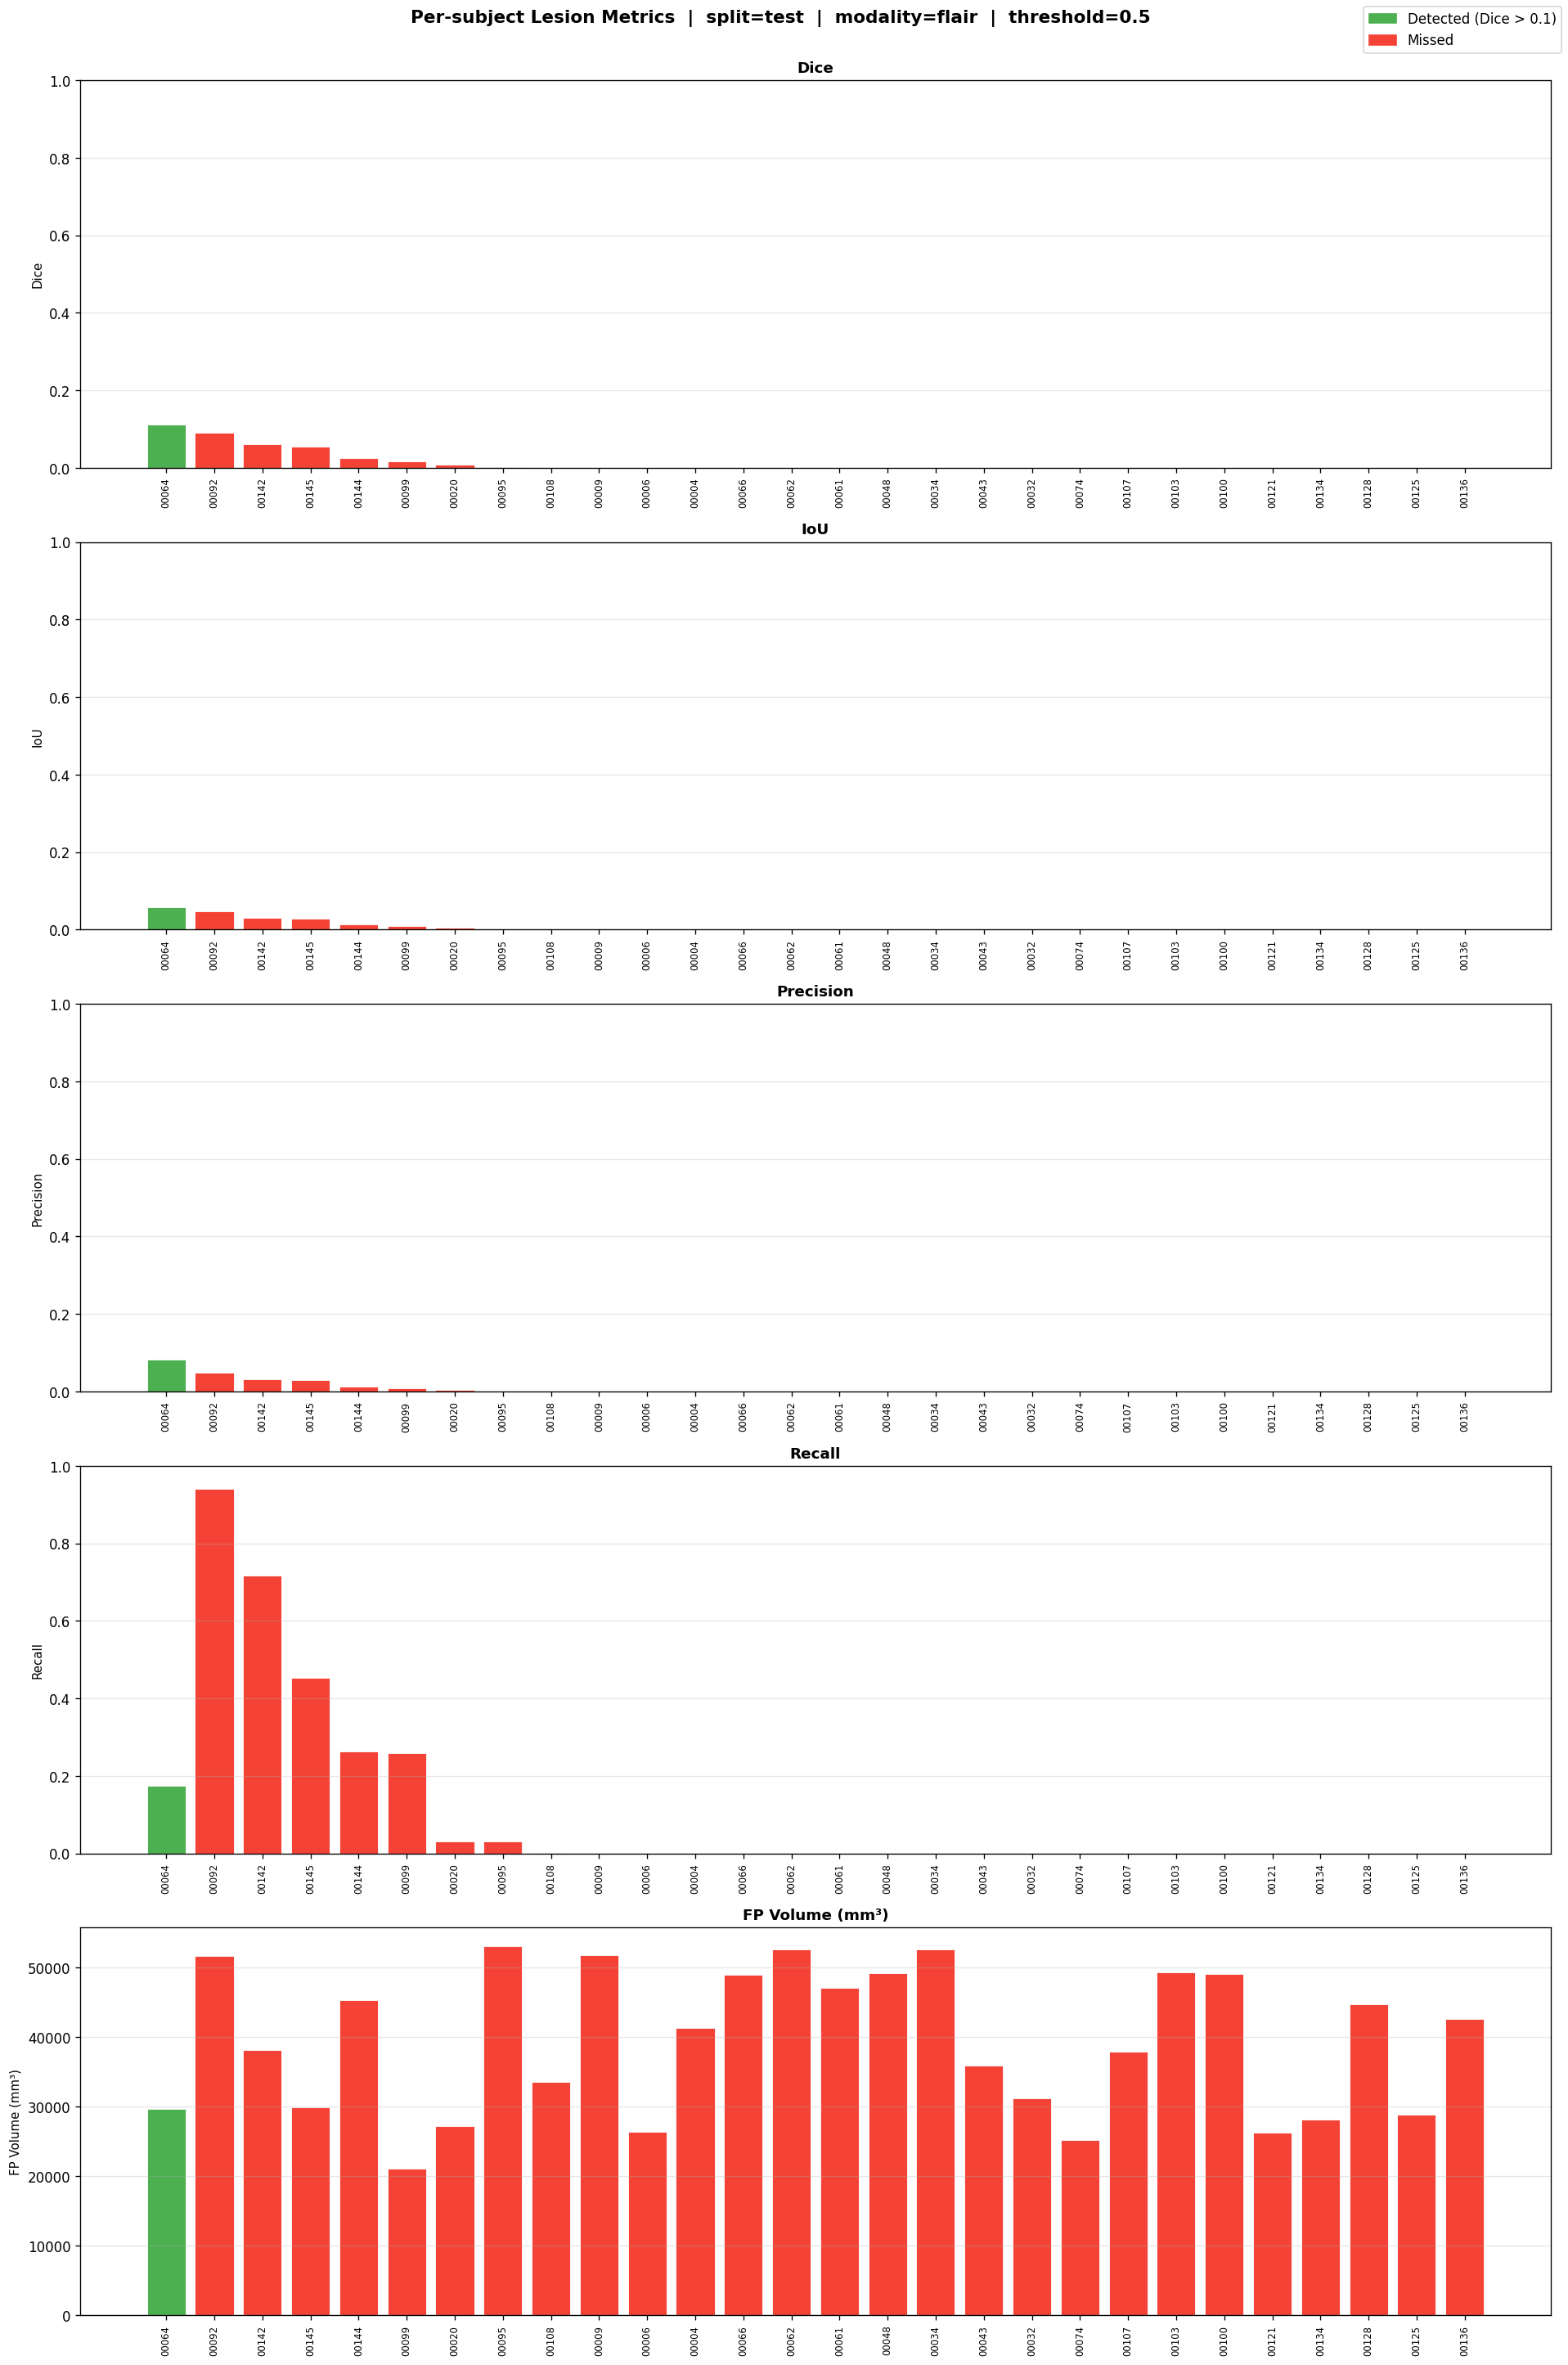

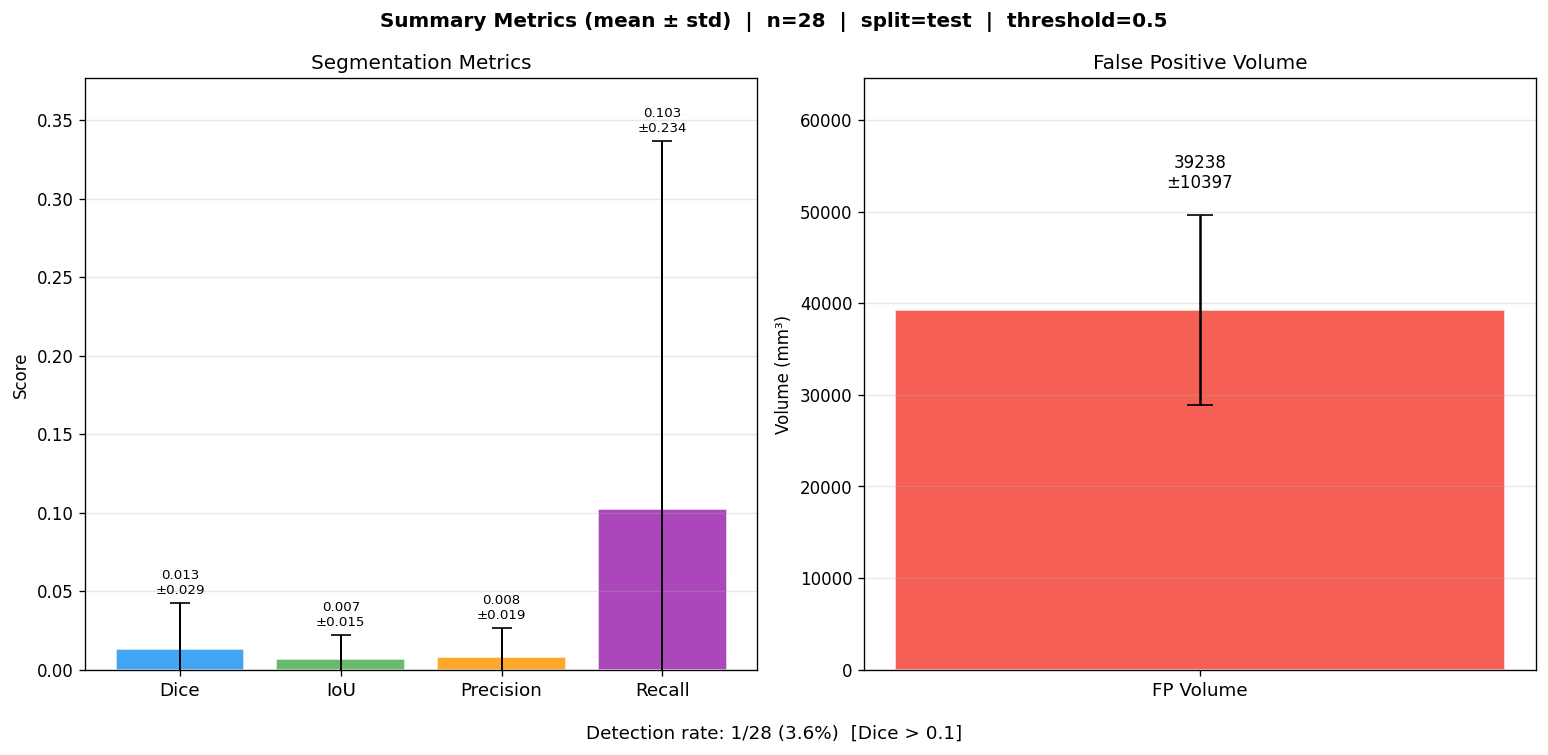

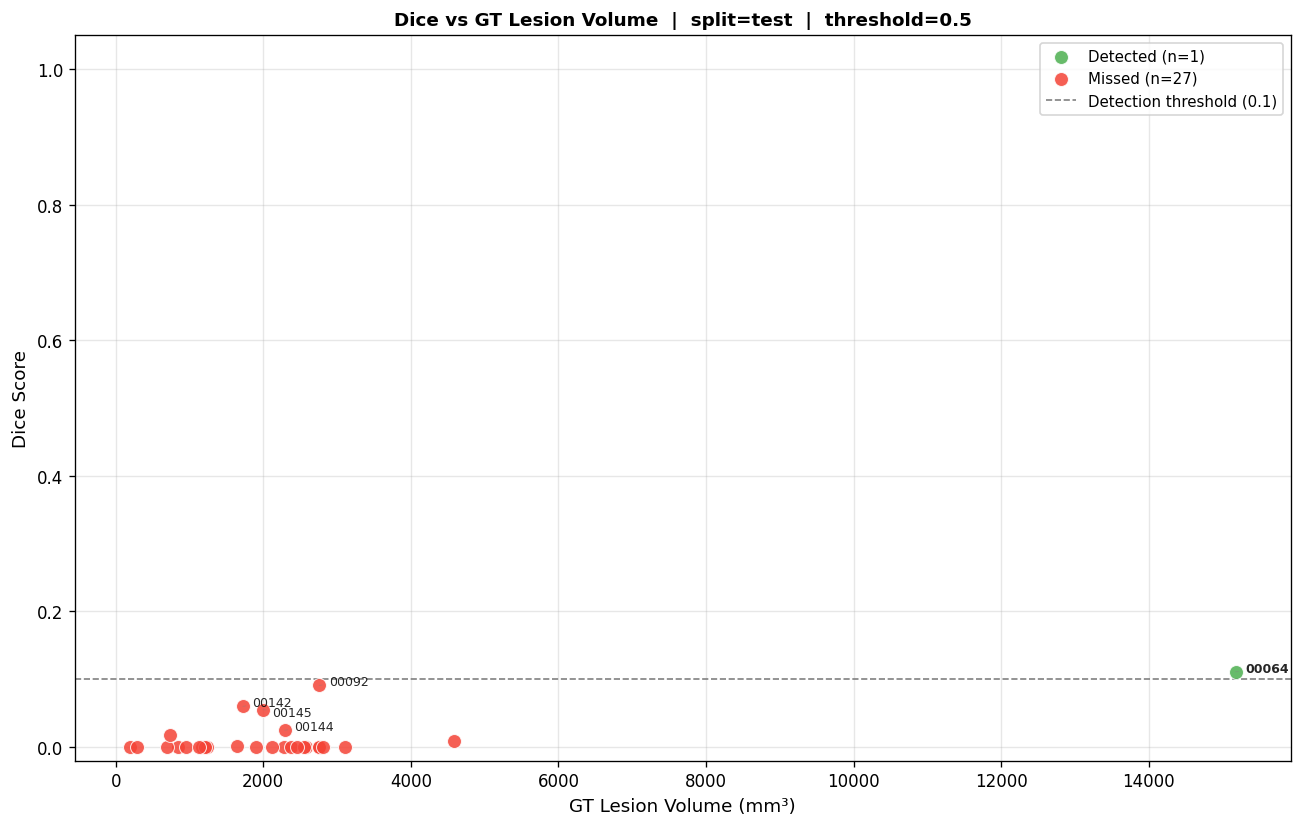

💡 Tip: pip install adjustText for better label placement in the scatter plot
Plots saved to /kaggle/working/inference_out/synthfcd_extra_data_flair/eval_lesion/plots


In [9]:
if not EVAL_LESION or not lesion_results:
    print("EVAL_LESION=False or no results — skipping lesion metrics.")
else:
    df_l = pd.DataFrame(lesion_results)
    mdir = out_lesion / "metrics"
    pdir = out_lesion / "plots"

    # ── Per-subject CSV ───────────────────────────────────────────────────────
    col_order = [
        "subject", "pool", "dice", "iou", "precision", "recall",
        "fp_volume_mm3", "gt_lesion_volume_mm3", "pred_lesion_volume_mm3", "detected",
    ]
    df_l[col_order].sort_values("subject").to_csv(mdir / "per_subject_metrics.csv", index=False)

    # ── Summary CSV ───────────────────────────────────────────────────────────
    metric_cols = ["dice", "iou", "precision", "recall", "fp_volume_mm3"]
    summary = df_l[metric_cols].agg(["mean", "std", "median", "min", "max"]).T
    summary.index.name = "metric"
    dr = df_l["detected"].mean()
    summary.loc["detection_rate"] = [dr, 0.0, dr, dr, dr]
    summary.to_csv(mdir / "summary_metrics.csv")

    print(f"Saved: {mdir / 'per_subject_metrics.csv'}")
    print(f"Saved: {mdir / 'summary_metrics.csv'}")
    print(f"\nDetection rate : {df_l['detected'].sum()}/{len(df_l)}  ({dr*100:.1f}%)  [Dice > {DETECTION_THRESHOLD}]")
    display(summary.round(4))

    # ── Plot 1: Per-subject 5-subplot bar chart ───────────────────────────────
    df_s   = df_l.sort_values("dice", ascending=False).reset_index(drop=True)
    n      = len(df_s)
    colors = ["#4CAF50" if d else "#F44336" for d in df_s["detected"]]
    x_pos  = np.arange(n)

    plot_specs = [
        ("dice",          "Dice",           [0, 1]),
        ("iou",           "IoU",            [0, 1]),
        ("precision",     "Precision",      [0, 1]),
        ("recall",        "Recall",         [0, 1]),
        ("fp_volume_mm3", "FP Volume (mm³)", None),
    ]

    fig, axes = plt.subplots(5, 1, figsize=(max(16, n * 0.5), 24))
    fig.suptitle(
        f"Per-subject Lesion Metrics  |  split={DATA_SPLIT}  |  "
        f"modality={INPUT_MODALITY}  |  threshold={THRESHOLD}",
        fontsize=13, fontweight="bold", y=1.002
    )

    for ax, (col, title, ylim) in zip(axes, plot_specs):
        vals = df_s[col].tolist()
        ax.bar(x_pos, vals, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylabel(title, fontsize=9)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(
            df_s["subject"].str.replace("sub-", "").tolist(),
            rotation=90, fontsize=7, ha="center"
        )
        if ylim:
            ax.set_ylim(ylim)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.grid(axis="y", alpha=0.3)
        # NO per-bar value labels — removed to eliminate overlap

    legend_patches = [
        mpatches.Patch(color="#4CAF50", label=f"Detected (Dice > {DETECTION_THRESHOLD})"),
        mpatches.Patch(color="#F44336", label="Missed"),
    ]
    fig.legend(handles=legend_patches, loc="upper right", fontsize=10)
    plt.tight_layout()
    fig.savefig(str(pdir / "per_subject_metrics.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── Plot 2: Summary mean ± std ────────────────────────────────────────────
    ratio_metrics = ["dice", "iou", "precision", "recall"]
    means  = [df_l[m].mean() for m in ratio_metrics]
    stds   = [df_l[m].std()  for m in ratio_metrics]
    labels = ["Dice", "IoU", "Precision", "Recall"]

    fp_mean = df_l["fp_volume_mm3"].mean()
    fp_std  = df_l["fp_volume_mm3"].std()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(
        f"Summary Metrics (mean ± std)  |  n={len(df_l)}  |  "
        f"split={DATA_SPLIT}  |  threshold={THRESHOLD}",
        fontsize=12, fontweight="bold"
    )

    bars = ax1.bar(range(4), means, yerr=stds, capsize=6,
                   color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"],
                   edgecolor="white", alpha=0.85,
                   error_kw=dict(capsize=6, elinewidth=1.2, clip_on=True))
    ax1.set_xticks(range(4))
    ax1.set_xticklabels(labels, fontsize=11)
    ax1.set_ylim(0, max(m + s for m, s in zip(means, stds)) + 0.04)
    ax1.set_ylabel("Score")
    ax1.set_title("Segmentation Metrics")
    ax1.grid(axis="y", alpha=0.3)
    for bar, mean, std in zip(bars, means, stds):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.004,    # above the error bar cap
            f"{mean:.3f}\n±{std:.3f}",
            ha="center", va="bottom", fontsize=8, color="black"
        )
    
    ax2.bar([0], [fp_mean], yerr=[fp_std], capsize=8,
            color="#F44336", edgecolor="white", alpha=0.85, width=0.4)
    ax2.set_xticks([0])
    ax2.set_xticklabels(["FP Volume"], fontsize=11)
    ax2.set_ylim(0, (fp_mean + fp_std) * 1.3)   # enough headroom for annotation
    ax2.set_ylabel("Volume (mm³)")
    ax2.set_title("False Positive Volume")
    ax2.grid(axis="y", alpha=0.3)
    ax2.text(
        0, (fp_mean + fp_std) * 1.05,
        f"{fp_mean:.0f}\n±{fp_std:.0f}",
        ha="center", va="bottom", fontsize=10
    )

    fig.text(
        0.5, -0.03,
        f"Detection rate: {df_l['detected'].sum()}/{len(df_l)} ({dr*100:.1f}%)  "
        f"[Dice > {DETECTION_THRESHOLD}]",
        ha="center", fontsize=11
    )
    plt.tight_layout()
    fig.savefig(str(pdir / "summary_metrics.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── Plot 3: Dice vs GT lesion volume ──────────────────────────────────────
    try:
        from adjustText import adjust_text
        has_adjustText = True
    except ImportError:
        has_adjustText = False

    detected   = df_l["detected"].values
    gt_vols    = df_l["gt_lesion_volume_mm3"].values
    dice_vals  = df_l["dice"].values
    sub_ids    = df_l["subject"].str.replace("sub-", "").values

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(gt_vols[ detected], dice_vals[ detected], c="#4CAF50", s=70,
               alpha=0.85, edgecolors="white", lw=0.6,
               label=f"Detected (n={detected.sum()})", zorder=3)
    ax.scatter(gt_vols[~detected], dice_vals[~detected], c="#F44336", s=70,
               alpha=0.85, edgecolors="white", lw=0.6,
               label=f"Missed (n={(~detected).sum()})", zorder=3)

    texts = []
    for sid, x, y, det in zip(sub_ids, gt_vols, dice_vals, detected):
        if det or y > 0.02:
            texts.append((x, y, sid, det))
    
    # Sort by y descending so we assign slots top to bottom
    texts = sorted(texts, key=lambda t: -t[1])
    
    FONT_SIZE   = 7.5
    Y_STEP      = 0.014   # minimum gap between label slots (~1 font size in data coords)
    used_y      = []      # list of already-assigned y positions
    
    def find_free_y(preferred_y):
        """Bump y down until it doesn't collide with any used slot."""
        y = preferred_y
        for taken in sorted(used_y):
            if abs(y - taken) < Y_STEP:
                y = taken - Y_STEP
        return y
    
    for x, y, sid, det in texts:
        label_y = find_free_y(y)
        used_y.append(label_y)
        ax.annotate(
            sid,
            xy=(x, y),
            xytext=(x + 130, label_y),
            fontsize=FONT_SIZE,
            fontweight="bold" if det else "normal",
            alpha=0.85,
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.4, alpha=0.5),
        )        
    # if adjustText not available, labels stay as-is (still better than before
    # because we stripped the "sub-" prefix, saving horizontal space)

    ax.axhline(DETECTION_THRESHOLD, color="gray", linestyle="--", linewidth=1,
               label=f"Detection threshold ({DETECTION_THRESHOLD})")
    ax.set_xlabel("GT Lesion Volume (mm³)", fontsize=11)
    ax.set_ylabel("Dice Score", fontsize=11)
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(
        f"Dice vs GT Lesion Volume  |  split={DATA_SPLIT}  |  threshold={THRESHOLD}",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(str(pdir / "dice_vs_lesion_volume.png"), dpi=120, bbox_inches="tight")
    plt.show()

    if not has_adjustText:
        print("💡 Tip: pip install adjustText for better label placement in the scatter plot")
    print(f"Plots saved to {pdir}")

## Full Segmentation Evaluation — Metrics & Plots
*Skipped if `EVAL_FULL_SEG=False`.*

Ground truth is `fusedmask.nii` remapped to model classes (0–6).

**CSVs:**
- `eval_full_seg/metrics/per_subject_per_class_dice.csv` — rows = subjects, cols = 7 class Dice + mean
- `eval_full_seg/metrics/summary_per_class.csv` — mean / std / median per class across subjects

**Plots:**
- `class_dice_heatmap.png` — subjects × 7 classes heatmap
- `per_class_summary.png` — mean Dice per class with std error bars
- `per_subject_mean_dice.png` — per-subject mean Dice bar chart

Saved: /kaggle/working/inference_out/synthfcd_extra_data_flair/eval_full_seg/metrics/per_subject_per_class_dice.csv
Saved: /kaggle/working/inference_out/synthfcd_extra_data_flair/eval_full_seg/metrics/summary_per_class.csv

Overall mean Dice across all classes: 0.589 ± 0.036


,mean,std,median,min,max
class,,,,,
Background,0.9731,0.0067,0.9749,0.9513,0.9812
White Matter,0.7991,0.0582,0.8146,0.5840,0.8536
Cerebral Cortex,0.5833,0.0852,0.5959,0.3354,0.6775
Deep Gray Matter,0.7686,0.0333,0.7763,0.6772,0.8186
CSF,0.5766,0.0647,0.5939,0.4283,0.6549
WM-GM Separator,0.4121,0.0458,0.4228,0.2582,0.4634
FCD Lesion,0.0084,0.0182,0.0000,0.0000,0.0658
Mean (all classes),0.5887,0.0356,0.5952,0.5002,0.6315


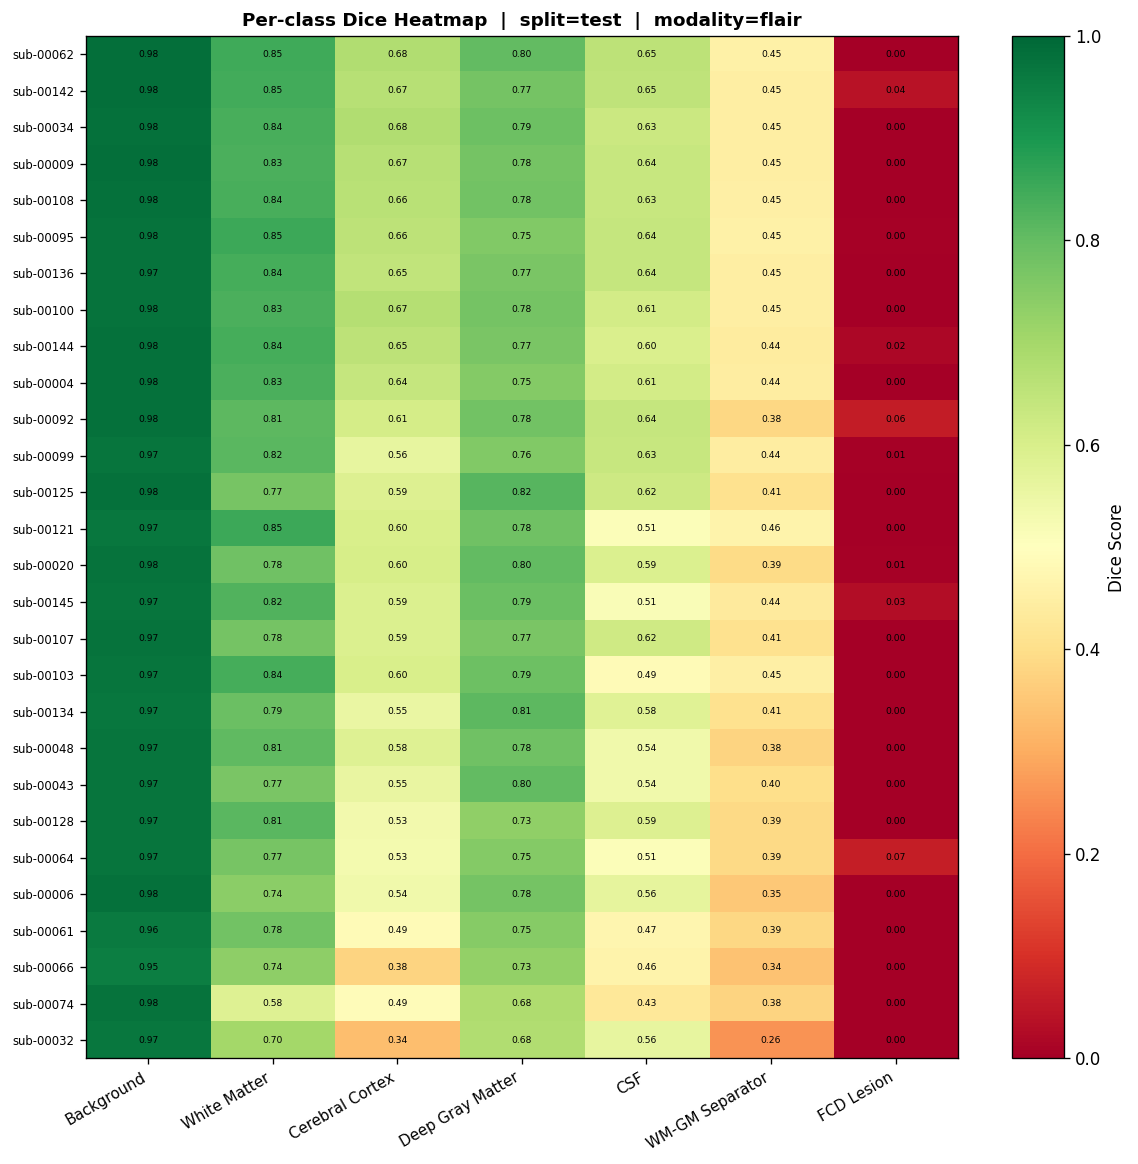

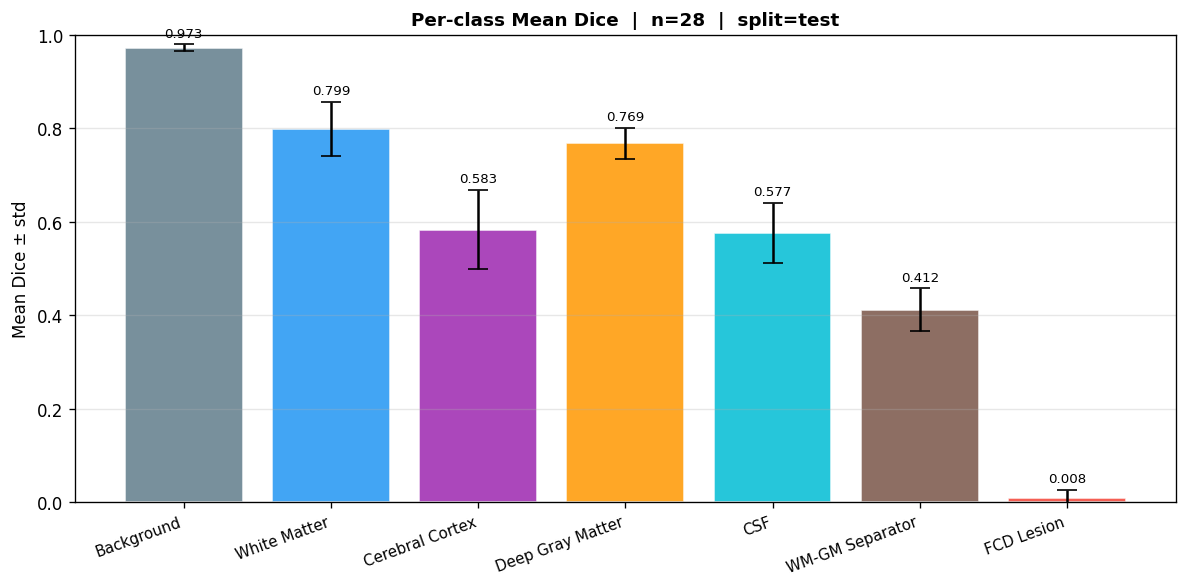

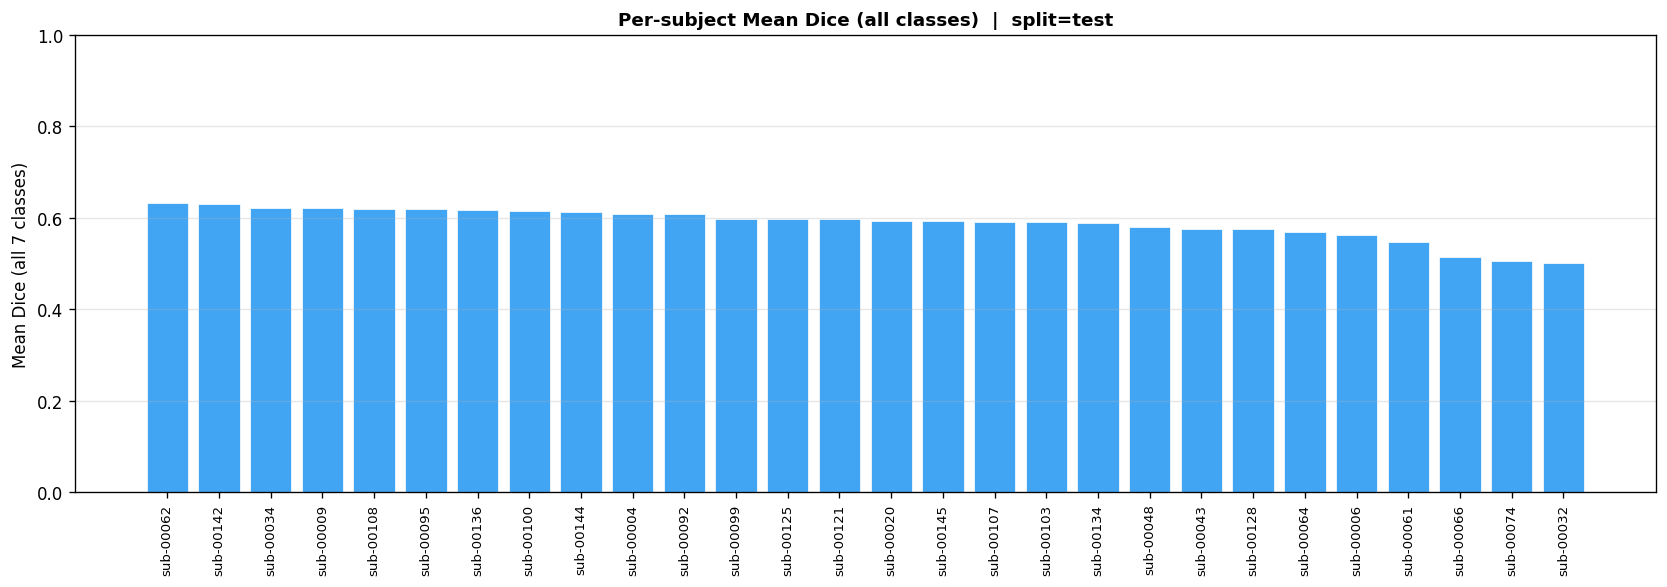

Plots saved to /kaggle/working/inference_out/synthfcd_extra_data_flair/eval_full_seg/plots


In [10]:
if not EVAL_FULL_SEG or not fullseg_results:
    print("EVAL_FULL_SEG=False or no results — skipping full-seg metrics.")
else:
    df_f = pd.DataFrame(fullseg_results)
    mdir = out_fullseg / "metrics"
    pdir = out_fullseg / "plots"

    dice_cols  = [f"dice_class_{c}" for c in range(NB_CLASSES)]

    # ── Per-subject CSV ───────────────────────────────────────────────────────
    col_order = ["subject", "pool"] + dice_cols + ["mean_dice"]
    df_f[col_order].sort_values("subject").to_csv(
        mdir / "per_subject_per_class_dice.csv", index=False
    )

    # ── Summary CSV ───────────────────────────────────────────────────────────
    summary_f = df_f[dice_cols + ["mean_dice"]].agg(["mean","std","median","min","max"]).T
    summary_f.index = CLASS_NAMES + ["Mean (all classes)"]
    summary_f.index.name = "class"
    summary_f.to_csv(mdir / "summary_per_class.csv")

    print(f"Saved: {mdir / 'per_subject_per_class_dice.csv'}")
    print(f"Saved: {mdir / 'summary_per_class.csv'}")
    print(f"\nOverall mean Dice across all classes: {df_f['mean_dice'].mean():.3f} ± {df_f['mean_dice'].std():.3f}")
    display(summary_f.round(4))

    # ── Plot 1: Heatmap — subjects × 7 classes ───────────────────────────────
    df_sorted  = df_f.sort_values("mean_dice", ascending=False).reset_index(drop=True)
    heat_data  = df_sorted[dice_cols].values        # (n_subjects, 7)
    sub_labels = df_sorted["subject"].tolist()

    fig, ax = plt.subplots(figsize=(10, max(6, len(sub_labels) * 0.35)))
    im = ax.imshow(heat_data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1,
                   interpolation="nearest")
    ax.set_xticks(range(NB_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(sub_labels)))
    ax.set_yticklabels(sub_labels, fontsize=7)
    ax.set_title(
        f"Per-class Dice Heatmap  |  split={DATA_SPLIT}  |  modality={INPUT_MODALITY}",
        fontsize=11, fontweight="bold"
    )
    plt.colorbar(im, ax=ax, label="Dice Score")
    # Annotate each cell
    for r in range(len(sub_labels)):
        for c in range(NB_CLASSES):
            ax.text(c, r, f"{heat_data[r,c]:.2f}", ha="center", va="center",
                    fontsize=5.5, color="black")
    plt.tight_layout()
    fig.savefig(str(pdir / "class_dice_heatmap.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── Plot 2: Per-class summary bar chart ───────────────────────────────────
    class_means = [df_f[f"dice_class_{c}"].mean() for c in range(NB_CLASSES)]
    class_stds  = [df_f[f"dice_class_{c}"].std()  for c in range(NB_CLASSES)]
    colors_cls  = ["#607D8B","#2196F3","#9C27B0","#FF9800","#00BCD4","#795548","#F44336"]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(range(NB_CLASSES), class_means, yerr=class_stds, capsize=6,
                  color=colors_cls, edgecolor="white", alpha=0.85)
    ax.set_xticks(range(NB_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1); ax.set_ylabel("Mean Dice ± std")
    ax.set_title(
        f"Per-class Mean Dice  |  n={len(df_f)}  |  split={DATA_SPLIT}",
        fontsize=11, fontweight="bold"
    )
    ax.grid(axis="y", alpha=0.3)
    for bar, mean, std in zip(bars, class_means, class_stds):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.01,
                f"{mean:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    fig.savefig(str(pdir / "per_class_summary.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── Plot 3: Per-subject mean Dice bar chart ───────────────────────────────
    fig, ax = plt.subplots(figsize=(max(14, len(df_sorted) * 0.4), 5))
    ax.bar(range(len(df_sorted)), df_sorted["mean_dice"], color="#2196F3",
           edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(sub_labels, rotation=90, fontsize=8)
    ax.set_ylabel("Mean Dice (all 7 classes)")
    ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)
    ax.set_title(
        f"Per-subject Mean Dice (all classes)  |  split={DATA_SPLIT}",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    fig.savefig(str(pdir / "per_subject_mean_dice.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Plots saved to {pdir}")

## Final Summary

In [11]:
print("\n" + "═"*54)
print("  ✅  Inference complete")
print("═"*54)
print(f"  Checkpoint       : {Path(CHECKPOINT_PATH).name}")
print(f"  Split            : {DATA_SPLIT}")
print(f"  Modality         : {INPUT_MODALITY}")
print(f"  Normalize        : {NORMALIZE}")
print(f"  Threshold        : {THRESHOLD}")
print(f"  Subjects total   : {len(subjects)}")
print(f"  Subjects failed  : {len(failures)}")

if EVAL_LESION and lesion_results:
    df_l = df_l if 'df_l' in dir() else pd.DataFrame(lesion_results)
    dr   = df_l["detected"].mean()
    print("  " + "─"*50)
    print(f"  EVAL_LESION")
    print(f"    Subjects evaluated : {len(df_l)}")
    print(f"    Detection rate     : {df_l['detected'].sum()}/{len(df_l)} ({dr*100:.1f}%)  [Dice > {DETECTION_THRESHOLD}]")
    print(f"    Mean Dice          : {df_l['dice'].mean():.3f} ± {df_l['dice'].std():.3f}")
    print(f"    Mean IoU           : {df_l['iou'].mean():.3f} ± {df_l['iou'].std():.3f}")
    print(f"    Mean Precision     : {df_l['precision'].mean():.3f} ± {df_l['precision'].std():.3f}")
    print(f"    Mean Recall        : {df_l['recall'].mean():.3f} ± {df_l['recall'].std():.3f}")
    print(f"    Mean FP Volume     : {df_l['fp_volume_mm3'].mean():.0f} ± {df_l['fp_volume_mm3'].std():.0f} mm³")

if EVAL_FULL_SEG and fullseg_results:
    df_f = df_f if 'df_f' in dir() else pd.DataFrame(fullseg_results)
    print("  " + "─"*50)
    print(f"  EVAL_FULL_SEG")
    print(f"    Subjects evaluated : {len(df_f)}")
    print(f"    Mean Dice (all cls): {df_f['mean_dice'].mean():.3f} ± {df_f['mean_dice'].std():.3f}")
    for c, name in enumerate(CLASS_NAMES):
        col = f"dice_class_{c}"
        print(f"    {name:<22s}: {df_f[col].mean():.3f} ± {df_f[col].std():.3f}")

print("  " + "─"*50)
print(f"  Output dir         : {OUTPUT_DIR}")
print(f"  predictions/       → _seg.nii + _lesion.nii per subject")
if EVAL_LESION and lesion_results:
    print(f"  eval_lesion/       → metrics/ + plots/")
if EVAL_FULL_SEG and fullseg_results:
    print(f"  eval_full_seg/     → metrics/ + plots/")
print("═"*54)


══════════════════════════════════════════════════════
  ✅  Inference complete
══════════════════════════════════════════════════════
  Checkpoint       : checkpoint-epoch=133-eval_loss=3.27-val_dice=0.58.ckpt
  Split            : test
  Modality         : flair
  Normalize        : False
  Threshold        : 0.5
  Subjects total   : 28
  Subjects failed  : 0
  ──────────────────────────────────────────────────
  EVAL_LESION
    Subjects evaluated : 28
    Detection rate     : 1/28 (3.6%)  [Dice > 0.1]
    Mean Dice          : 0.013 ± 0.029
    Mean IoU           : 0.007 ± 0.015
    Mean Precision     : 0.008 ± 0.019
    Mean Recall        : 0.103 ± 0.234
    Mean FP Volume     : 39238 ± 10397 mm³
  ──────────────────────────────────────────────────
  EVAL_FULL_SEG
    Subjects evaluated : 28
    Mean Dice (all cls): 0.589 ± 0.036
    Background            : 0.973 ± 0.007
    White Matter          : 0.799 ± 0.058
    Cerebral Cortex       : 0.583 ± 0.085
    Deep Gray Matter      : 0.